# Exploratory Data Analysis (EDA)

1.   How many Movies vs TV Shows are there?
2.   Which countries produce the most Netflix content?
1.   How has the number of releases changed over the years?
2.   What are the most common content ratings?
1.   Which directors have the most titles on Netflix?
2.   Which genres are most common?
1.   When was most content added to Netflix?

#Load the Dataset

In [53]:
#Connect with google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside Colab
%matplotlib inline

In [55]:
#Import Data Set
df = pd.read_csv("/content/drive/MyDrive/CodeAlpha/netflix_titles.csv")

# Dataset Summary

In [56]:
#General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [57]:
#Dataset shape
print(df.shape)

(8807, 12)


In [58]:
#Column names
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [59]:
#Data types
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [60]:
#Display first 5 rows
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [61]:
#Summary statistics
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


#Data Cleaning

In [62]:
#Missing Value Handling
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


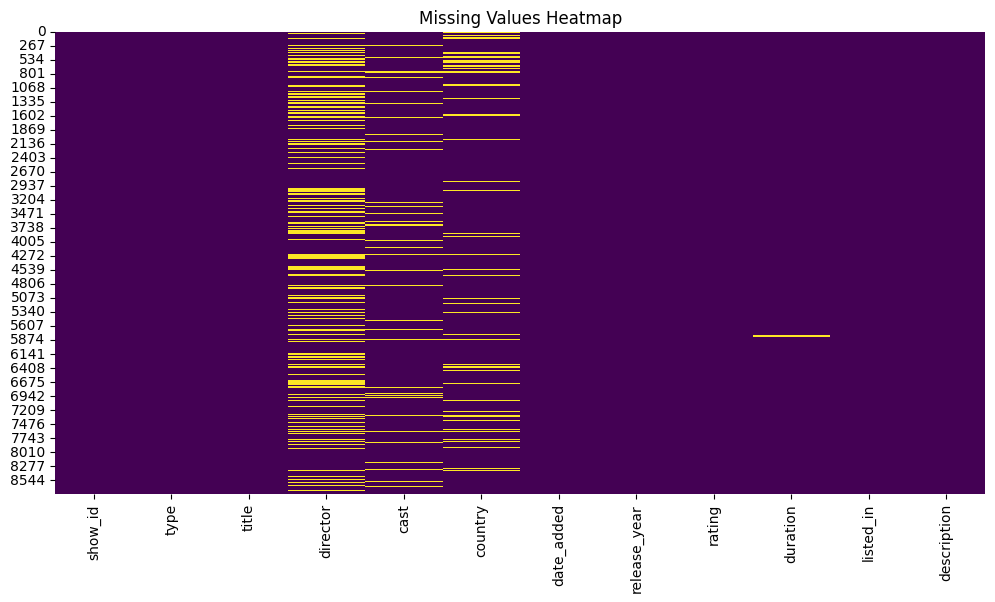

In [63]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [64]:
# Fill missing values
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna(df["country"].mode()[0])
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

# Remove rows with missing date_added
df = df.dropna(subset=["date_added"])

In [65]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


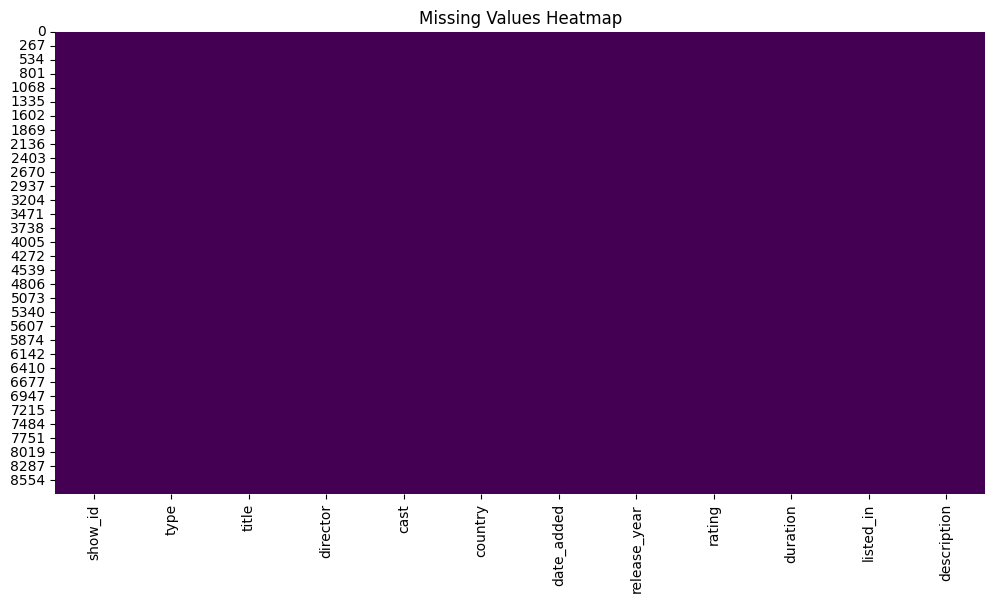

In [66]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [67]:
#Duplicate Value Handling
df.duplicated().sum()

np.int64(0)

In [68]:
#Drop Duplicates
df = df.drop_duplicates()

In [69]:
df.duplicated().sum()

np.int64(0)

#Identify Trends and Patterns

In [70]:
#Movies vs TV Shows
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2666


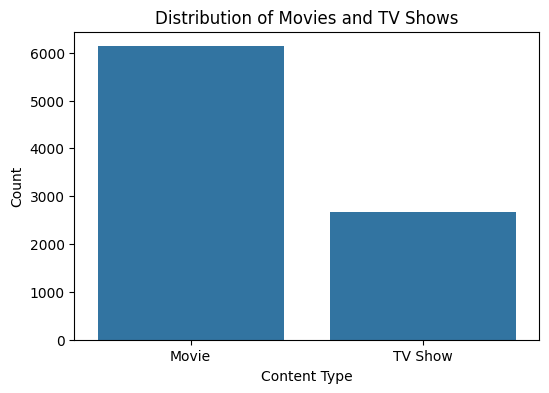

In [71]:
plt.figure(figsize=(6,4))

sns.countplot(x="type", data=df)

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

Movies are more common than TV Shows in the Netflix dataset.

In [72]:
#Releases by year
df["release_year"].value_counts().sort_index()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1146
2019,1030


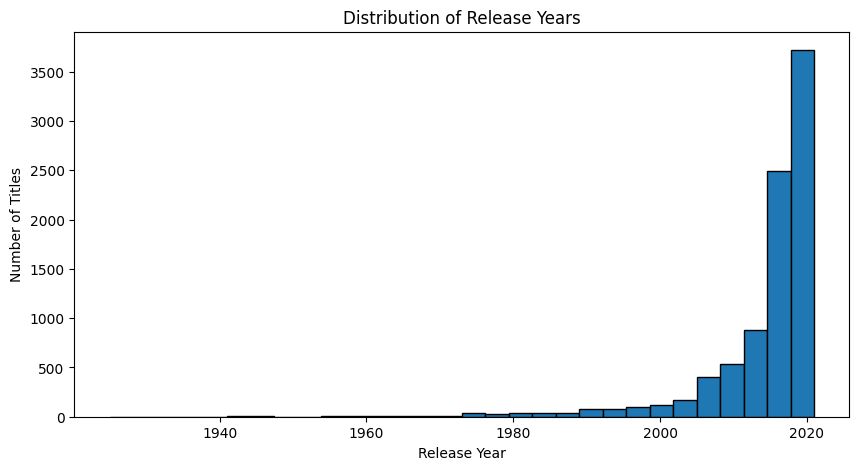

In [73]:
plt.figure(figsize=(10,5))

plt.hist(df["release_year"],
         bins=30,
         edgecolor="black")

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

Most Netflix titles were released in recent years, showing rapid growth in content production.

In [74]:
#Top countries
df["country"].value_counts().head(10)

,count
country,
United States,3642
India,972
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


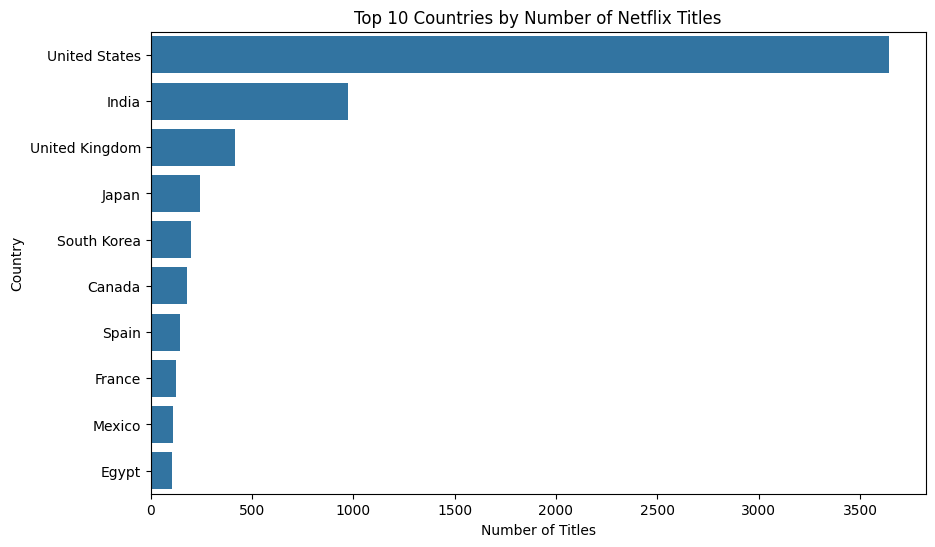

In [75]:
plt.figure(figsize=(10,6))

top_countries = df["country"].value_counts().head(10)

sns.barplot(x=top_countries.values,
            y=top_countries.index)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

The United States has the highest number of Netflix titles, followed by India and the United Kingdom

In [76]:
#Ratings
df["rating"].value_counts()

,count
rating,
TV-MA,3209
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


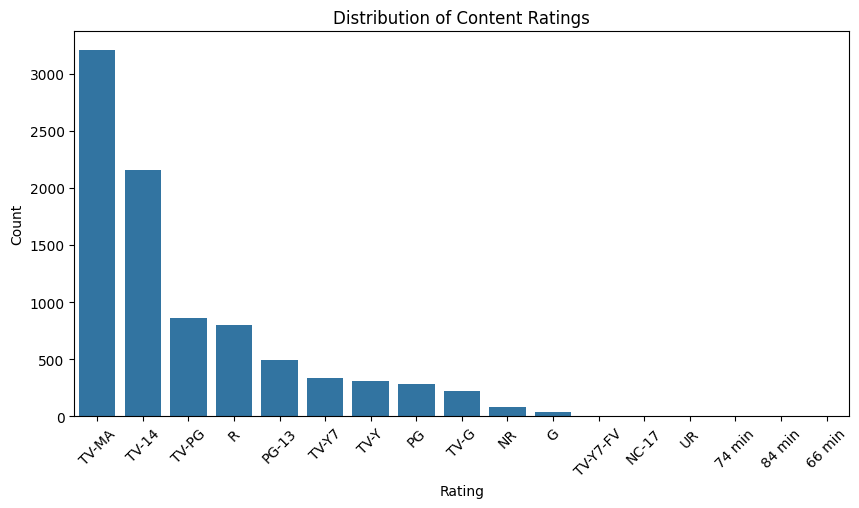

In [77]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="rating",
    order=df["rating"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

TV-MA and TV-14 are among the most frequent content ratings.

#Test Hypotheses

In [78]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2666


In [79]:
df[df["release_year"] >= 2015].shape

(6212, 12)

In [80]:
df["country"].value_counts().head()

,count
country,
United States,3642
India,972
United Kingdom,418
Japan,244
South Korea,199


#Detect Data Issues

*   Missing values in several columns
*   Missing directors/cast information
*   Multiple countries stored in a single field
*   date_added stored as text and may require conversion to datetime
*   Some categorical columns contain "Unknown" after preprocessing










#Conclusions

This exploratory data analysis examined the Netflix titles dataset by exploring its structure, cleaning missing values, analyzing trends, and testing hypotheses. The analysis showed that Movies dominate the platform, the United States contributes the largest share of content, and most titles were released in recent years. After preprocessing, the dataset is suitable for further analysis and visualization.

#